# SHAP Feature Importance Demo

In [1]:
# set path to H2O Sonar Git repository
H2O_SONAR_HOME = "~/h/mli/git/h2o-sonar"
import os
H2O_SONAR_HOME = os.path.expanduser(H2O_SONAR_HOME)
os.chdir(H2O_SONAR_HOME)

In [8]:
import pandas as pd
import datatable as dt
from sklearn.ensemble import GradientBoostingClassifier

from mli import interpret
from mli.explainer._shap import Shap
from mli.lib.api.models import ExplainableModel, ExplainableModelType, ExplainableModelMeta, SanitizationMap
from mli.lib.api.datasets import ExplainableDataset
from mli.lib.api.models import ModelApi

In [9]:
df = pd.read_csv(os.path.join(MLIBRARY_HOME, "data/predictive/creditcard.csv"))

In [10]:
target_col = "default payment next month"
X,y = df.drop(target_col,axis=1), df[target_col]

In [11]:
gradient_booster = GradientBoostingClassifier(learning_rate=0.1)
gradient_booster.fit(X, y)

GradientBoostingClassifier()

In [12]:
sk_model = ModelApi().create_model(model_src=gradient_booster, target_col=target_col)

# sk_model = ExplainableModel(predict_method=gradient_booster.predict,
#                             model_src=gradient_booster)

In [13]:
# SHAP
shap = Shap(explainable_model=sk_model, output_names=list(X.columns))

shap_values = shap.explain(X)

In [14]:
shap_values

,bias,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,…,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,−1.44588,1.67078,0.0802907,−0.0250105,9.40194e-05,0.0835094,0.0657334,0.0533467,0.207667,−0.0702868,…,0.0821963,0.217298,0.26758,0.0126089,0.0364352
1,−1.44588,1.31607,0.00129194,−0.0123465,−0.00232935,−0.0161834,−0.0188383,−0.143019,0.239475,−0.058448,…,0.109182,−0.11174,−0.0537193,0.00894618,−0.00107461
2,−1.44588,−0.470893,−0.017342,−0.00589474,−0.00454894,−0.0497109,−0.0118036,−0.287093,−0.0213871,−0.0607516,…,0.0811547,−0.116265,−0.0504575,0.000679293,0.0120523
3,−1.44588,−0.510613,0.141898,−0.0156181,−0.00245013,0.0461385,−0.00380024,0.319875,−0.00856697,−0.0372343,…,0.00332664,−0.103682,−0.0544091,−0.0105598,−0.0362038
4,−1.44588,−0.746888,0.010493,0.0161891,−0.00172247,0.0720904,0.0716501,1.36139,0.000827251,−0.244813,…,−0.399411,−0.0372833,−0.044835,−0.000942927,0.0203322
5,−1.44588,−0.78355,0.102478,0.00713059,−0.000546858,−0.0501176,−0.00889622,1.48871,0.00274979,−0.0266434,…,0.0428576,−0.0404473,−0.0565432,0.00270416,0.0316379
6,−1.44588,−0.677477,−0.196359,0.00602184,−0.000863733,−0.0624833,−0.0102786,1.07069,0.00143372,−0.0399313,…,−0.475642,−0.200231,−0.049845,−0.0670877,−0.17778
7,−1.44588,−0.796601,−0.0597843,−0.00561376,−0.00403961,−0.0291708,0.0441736,1.03034,−0.0495203,−0.237952,…,0.0546683,0.207076,−0.0919201,0.0048929,−0.00744675
8,−1.44588,−0.839001,0.00210427,−0.00985364,−0.0220644,0.0413874,−0.00790787,1.10472,9.20288e-05,0.334631,…,0.068561,0.0604274,−0.0555055,0.00130089,−0.0212786


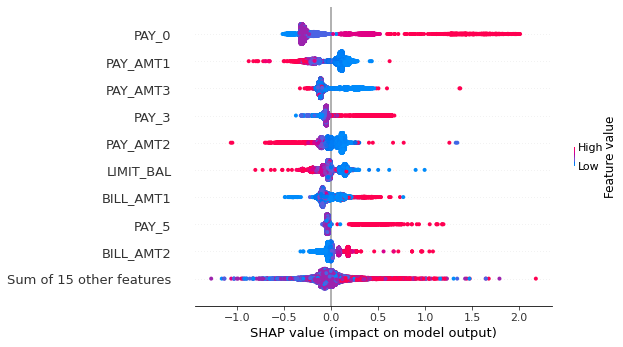

In [15]:
shap.plot()

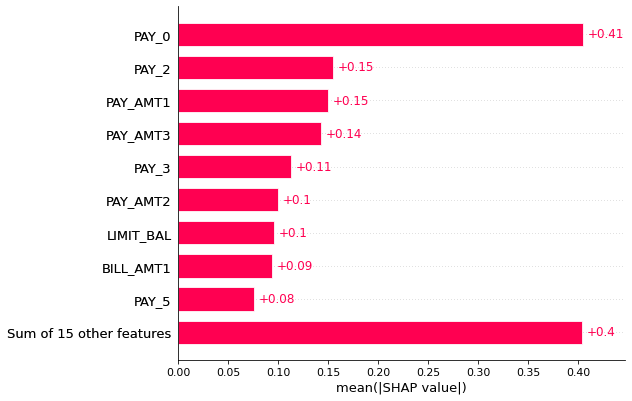

In [16]:
shap.plot(plot_type="bar")